In [159]:
import torch
import sys
import math
import pickle
import time
import numpy as np
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from dateutil.relativedelta import relativedelta
from datetime import datetime
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

In [160]:
%reload_ext watermark
%watermark -a "Matheus dos Anjos" --iversions

Author: Matheus dos Anjos

dateutil  : 2.9.0.post0
tqdm      : 4.66.5
torch     : 2.7.1
numpy     : 1.26.4
sklearn   : 1.5.1
sys       : 3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
pandas    : 2.2.2
matplotlib: 3.9.2



In [161]:
df = pd.read_csv('C:/Users/conta/OneDrive/Desktop/Projetos-/Projetos Python/exercicios_Series_Temporais/Dados/train.csv')

In [162]:
df.shape

(90000, 5)

In [163]:
df.head()

,Id,Timestep,Course,Faculty,Expected
0,0,AY1810-AY1811,VX27870,Prof. Jadon Haney,386
1,1,AY1810-AY1811,SN11041,Prof. Kennedy Shields,158
2,2,AY1810-AY1811,CG17623,Prof. Brandon Silva,303
3,3,AY1810-AY1811,GW27856,Prof. Lorena Mays,207
4,4,AY1810-AY1811,SI10212,Prof. Haleigh Romero,329


In [164]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90000 entries, 0 to 89999
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Id        90000 non-null  int64 
 1   Timestep  90000 non-null  object
 2   Course    90000 non-null  object
 3   Faculty   90000 non-null  object
 4   Expected  90000 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 3.4+ MB


In [165]:
df = df.drop(columns = ['Faculty', 'Course'])

In [166]:
X = df['Timestep']

In [167]:
X_new = [None] * 90000

In [168]:
print(X)

0        AY1810-AY1811
1        AY1810-AY1811
2        AY1810-AY1811
3        AY1810-AY1811
4        AY1810-AY1811
             ...      
89995    AY1986-AY1987
89996    AY1986-AY1987
89997    AY1986-AY1987
89998    AY1986-AY1987
89999    AY1986-AY1987
Name: Timestep, Length: 90000, dtype: object


In [169]:
for i in range(len(X)):
    X_new[i] = int(X[i][2:6])

In [170]:
print(X_new)

[1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 1810, 181

In [171]:
data_inicial = '1/1/1810'

In [172]:
formato_data = '%d/%m/%Y'

In [173]:
dtObjt = datetime.strptime(data_inicial, formato_data)

In [174]:
dtObjt

datetime.datetime(1810, 1, 1, 0, 0)

In [175]:
for i in range(len(X)):
    r = dtObjt + relativedelta(days = i)
    X_new[i] = r.date()

In [176]:
df['New'] = X_new

In [177]:
df = df.drop(columns = ['Timestep', 'Id'])

In [178]:
df = df.set_index('New')

In [179]:
df['Expected'] = df['Expected'].astype('float32')

In [180]:
df.count()

Expected    90000
dtype: int64

In [181]:
df.head()

,Expected
New,
1810-01-01,386.0
1810-01-02,158.0
1810-01-03,303.0
1810-01-04,207.0
1810-01-05,329.0


In [182]:
df.tail()

,Expected
New,
2056-05-25,476.0
2056-05-26,222.0
2056-05-27,295.0
2056-05-28,187.0
2056-05-29,1103.0


In [183]:
dados = df.values.astype('float32')

In [ ]:
def func_divide_dados_seq(dataset, 
                          start_index = 0, 
                          end_index = None, 
                          history_size = 13, 
                          step = 1):
    
    data = []
    
    start_index = start_index + history_size
    
    if end_index is None:
        end_index = len(dataset)
    
    for i in range(start_index, end_index):
        indices = range(i - history_size, i, step)
        data.append(dataset[indices])
    
    return np.array(data)

In [ ]:
def func_separa_dados(data, TRAIN_SPLIT = 0.8, VAL_SPLIT = 0.6):
    
    data_mean = data.mean(axis = 0)
    
    data_std = data.std(axis = 0)
    
    data = (data - data_mean) / data_std
    
    stats = (data_mean, data_std)

    seq_dados = func_divide_dados_seq(data, 
                                      start_index = 0, 
                                      end_index = None, 
                                      history_size = 13, 
                                      step = 1)

    treino, valid = train_test_split(seq_dados, 
                                     train_size = TRAIN_SPLIT, 
                                     shuffle = True, 
                                     random_state = 123)
    
    valid, teste = train_test_split(seq_dados, 
                                    train_size = VAL_SPLIT, 
                                    shuffle = True, 
                                    random_state = 123)

    return treino, valid, teste

In [ ]:
def func_separa_input_target(separador):
    
    inputs = torch.tensor(separador[:, :-1, :], device = device)
    targets = torch.tensor(separador[:, 1:, :], device = device)
    
    return inputs, targets

In [ ]:
def func_prepara_dados_finais(train_data, 
                              val_data, 
                              test_data, 
                              batch_size = 32, 
                              target_features = list(range(1))):
    
    x_treino, y_treino = func_separa_input_target(train_data)
    x_val, y_val = func_separa_input_target(val_data)
    x_teste, y_teste = func_separa_input_target(test_data)

    dataset_treino = torch.utils.data.TensorDataset(x_treino, y_treino)
    dataset_valid = torch.utils.data.TensorDataset(x_val, y_val)
    dataset_teste = torch.utils.data.TensorDataset(x_teste, y_teste)

    loader_treino = torch.utils.data.DataLoader(dataset_treino, batch_size = batch_size)
    loader_valid = torch.utils.data.DataLoader(dataset_valid, batch_size = batch_size)
    loader_teste = torch.utils.data.DataLoader(dataset_teste, batch_size = batch_size)
    
    return loader_treino, loader_valid, loader_teste

In [188]:
dados_treino, dados_valid, dados_teste = func_separa_dados(dados)

In [189]:
print(dados)

[[ 386.]
 [ 158.]
 [ 303.]
 ...
 [ 295.]
 [ 187.]
 [1103.]]


In [190]:
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [191]:

dataset_treino_final, dataset_valid_final, dataset_teste_final = func_prepara_dados_finais(dados_treino, 
                                                                                           dados_valid, 
                                                                                           dados_teste)

In [ ]:
class MultiHeadAttention(nn.Module):

    def __init__(self, D, H):
        super(MultiHeadAttention, self).__init__()
        
        self.H = H 

        self.D = D 
        
        self.wq = nn.Linear(D, D*H)
        self.wk = nn.Linear(D, D*H)
        self.wv = nn.Linear(D, D*H)
        self.dense = nn.Linear(D*H, D)

    def concat_heads(self, x):
        
        B, H, S, D = x.shape
        x = x.permute((0, 2, 1, 3)).contiguous()  
        x = x.reshape((B, S, H*D))   
        
        return x

    def split_heads(self, x):
        
        B, S, D_H = x.shape
        x = x.reshape(B, S, self.H, self.D)   
        x = x.permute((0, 2, 1, 3))  
        return x

    def forward(self, x, mask):

        q = self.wq(x) 
        k = self.wk(x)  
        v = self.wv(x) 

        q = self.split_heads(q)  
        k = self.split_heads(k)  
        v = self.split_heads(v)  

        attention_scores = torch.matmul(q, k.transpose(-1, -2)) 
        attention_scores = attention_scores / math.sqrt(self.D)

        if mask is not None:
            attention_scores += (mask * -1e9)
        
        attention_weights = nn.Softmax(dim=-1)(attention_scores)
        scaled_attention = torch.matmul(attention_weights, v)  
        concat_attention = self.concat_heads(scaled_attention) 
        output = self.dense(concat_attention) 

        return output, attention_weights

In [193]:
B, S, H, D = 9, 11, 5, 8

In [194]:
mha = MultiHeadAttention(D, H)

In [195]:
out, att = mha.forward(torch.zeros(B, S, D), mask=None)

In [196]:
out.shape, att.shape

(torch.Size([9, 11, 8]), torch.Size([9, 5, 11, 11]))

In [197]:
def get_angles(pos, i, D):
    angle_rates = 1 / np.power(10000, (2 * (i // 2)) / np.float32(D))
    return pos * angle_rates

In [198]:
def positional_encoding(D, position=20, dim=3, device=device):
    
    angle_rads = get_angles(np.arange(position)[:, np.newaxis], np.arange(D)[np.newaxis, :], D)
    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    if dim == 3:
        pos_encoding = angle_rads[np.newaxis, ...]
    elif dim == 4:
        pos_encoding = angle_rads[np.newaxis, np.newaxis, ...]
    return torch.tensor(pos_encoding, device = device)

In [199]:
def create_look_ahead_mask(size, device = device):

    mask = torch.ones((size, size), device = device)
    mask = torch.triu(mask, diagonal = 1)

    return mask

In [200]:
create_look_ahead_mask(6)

tensor([[0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0., 0.]])

In [ ]:
class TransformerLayer(nn.Module):
    
    def __init__(self, D, H, hidden_mlp_dim, dropout_rate):
        
        super(TransformerLayer, self).__init__()
        
        self.dropout_rate = dropout_rate
        
        self.mlp_hidden = nn.Linear(D, hidden_mlp_dim)
        
        self.mlp_out = nn.Linear(hidden_mlp_dim, D)
        
        self.layernorm1 = nn.LayerNorm(D, eps=1e-9)
        
        self.layernorm2 = nn.LayerNorm(D, eps=1e-9)
        
        self.dropout1 = nn.Dropout(dropout_rate)
        
        self.dropout2 = nn.Dropout(dropout_rate)

        self.mha = MultiHeadAttention(D, H)

    def forward(self, x, look_ahead_mask):
        
        attn, attn_weights = self.mha(x, look_ahead_mask)  
        
        attn = self.dropout1(attn)
        
        attn = self.layernorm1(attn + x) 

        mlp_act = torch.relu(self.mlp_hidden(attn))
        
        mlp_act = self.mlp_out(mlp_act)
        
        mlp_act = self.dropout2(mlp_act)
        
        output = self.layernorm2(mlp_act + attn) 

        return output, attn_weights

In [202]:
d1 = TransformerLayer(16, 3, 32, 0.1)

In [203]:
out, attn = d1(x = torch.zeros(5, 7, 16), look_ahead_mask = None)

In [204]:
out.shape, attn.shape

(torch.Size([5, 7, 16]), torch.Size([5, 3, 7, 7]))

In [ ]:
class Transformer(nn.Module):

    def __init__(self, num_layers, D, H, hidden_mlp_dim, inp_features, out_features, dropout_rate):
        
        super(Transformer, self).__init__()
        
        self.sqrt_D = torch.tensor(math.sqrt(D))
        
        self.num_layers = num_layers
        
        self.input_projection = nn.Linear(inp_features, D) 
        
        self.output_projection = nn.Linear(D, out_features) 
        
        self.pos_encoding = positional_encoding(D, position=13)
        
        self.dec_layers = nn.ModuleList([TransformerLayer(D, H, hidden_mlp_dim, 
                                        dropout_rate = dropout_rate
                                       ) for _ in range(num_layers)])
        
        self.dropout = nn.Dropout(dropout_rate)

    def forward(self, x, mask):
        
        B, S, D = x.shape
        
        attention_weights = {}
        
        x = self.input_projection(x)
        
        x *= self.sqrt_D
        
        x += self.pos_encoding[:, :S, :]

        x = self.dropout(x)

        for i in range(self.num_layers):
            x, block = self.dec_layers[i](x = x, look_ahead_mask = mask)
            
            attention_weights['decoder_layer{}'.format(i + 1)] = block
        
        x = self.output_projection(x)
        
        return x, attention_weights 

In [ ]:
transformer = Transformer(num_layers = 3, 
                          D = 32, 
                          H = 1, 
                          hidden_mlp_dim = 32,
                          inp_features = 1, 
                          out_features = 1, 
                          dropout_rate = 0.1)

In [ ]:
transformer.to(device)

Transformer(
  (input_projection): Linear(in_features=1, out_features=32, bias=True)
  (output_projection): Linear(in_features=32, out_features=1, bias=True)
  (dec_layers): ModuleList(
    (0-2): 3 x TransformerLayer(
      (mlp_hidden): Linear(in_features=32, out_features=32, bias=True)
      (mlp_out): Linear(in_features=32, out_features=32, bias=True)
      (layernorm1): LayerNorm((32,), eps=1e-09, elementwise_affine=True)
      (layernorm2): LayerNorm((32,), eps=1e-09, elementwise_affine=True)
      (dropout1): Dropout(p=0.1, inplace=False)
      (dropout2): Dropout(p=0.1, inplace=False)
      (mha): MultiHeadAttention(
        (wq): Linear(in_features=32, out_features=32, bias=True)
        (wk): Linear(in_features=32, out_features=32, bias=True)
        (wv): Linear(in_features=32, out_features=32, bias=True)
        (dense): Linear(in_features=32, out_features=32, bias=True)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
)

In [ ]:
(inputs, targets) = next(iter(dataset_treino_final))

In [ ]:
S = inputs.shape[1]

In [210]:
S

12

In [ ]:
mask = create_look_ahead_mask(S)

In [ ]:
out, attn = transformer(x = inputs.float(), mask = mask)

In [214]:
out.shape, attn["decoder_layer1"].shape

(torch.Size([32, 12, 1]), torch.Size([32, 1, 12, 12]))

In [215]:
param_sizes = [p.numel() for p in transformer.parameters()]

In [216]:
print(f"Vamos treinar um total de {np.sum(param_sizes)} parâmetros (pesos) do modelo.")

Vamos treinar um total de 19489 parâmetros (pesos) do modelo.


In [ ]:
modelo_transformer = Transformer(num_layers = 3, 
                                 D = 32, 
                                 H = 4, 
                                 hidden_mlp_dim = 32, 
                                 inp_features = 1, 
                                 out_features = 1, 
                                 dropout_rate = 0.1).to(device)

In [ ]:
optimizer = torch.optim.RMSprop(modelo_transformer.parameters(), lr = 0.00005)

In [223]:
n_epochs = 5

In [224]:
niter = len(dataset_treino_final)

In [225]:
losses, val_losses = [], []

In [ ]:
%%time

for e in tqdm(range(n_epochs)):
    
    modelo_transformer.train()
    
    sum_train_loss = 0.0

    for x, y in dataset_treino_final:
        
        S = x.shape[1]
        
        mask = create_look_ahead_mask(S)
        
        out, _ = modelo_transformer(x.float(), mask)
        
        loss = torch.nn.MSELoss()(out, y)
        
        sum_train_loss += loss.item()
        
        loss.backward()
        
        optimizer.step()
        
    losses.append(sum_train_loss / niter)
    
    modelo_transformer.eval()
    
    sum_val_loss = 0.0
    
    for i, (x, y) in enumerate(dataset_valid_final):
        
        S = x.shape[1]
        
        mask = create_look_ahead_mask(S)
        
        out, _ = modelo_transformer(x, mask)
        
        loss = torch.nn.MSELoss()(out, y)
        
        sum_val_loss += loss.item()
        
    val_losses.append(sum_val_loss / (i + 1))

100%|██████████| 5/5 [03:23<00:00, 40.69s/it]

CPU times: total: 25min 15s
Wall time: 3min 23s


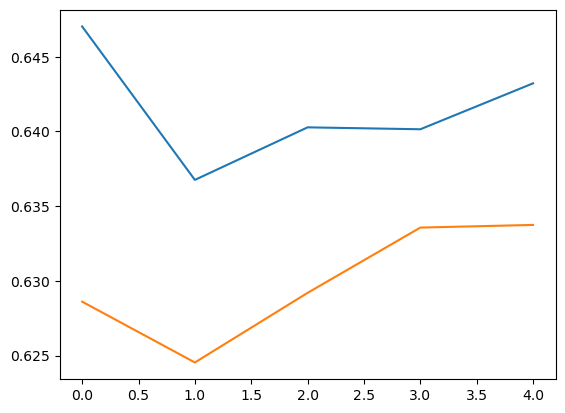

In [ ]:
plt.plot(losses)
plt.plot(val_losses)

In [234]:
nome_modelo = 'C:/Users/conta/OneDrive/Desktop/Projetos-/Projetos Python/exercicios_Series_Temporais/modelo_transformer.sav'

In [ ]:
pickle.dump(modelo_transformer, open(nome_modelo, 'wb'))

In [ ]:
modelo_final = pickle.load(open(nome_modelo, 'rb'))

In [237]:
type(dataset_teste_final)

torch.utils.data.dataloader.DataLoader

In [238]:
test_losses, test_preds = [], []

In [239]:
modelo_final.eval()

Transformer(
  (input_projection): Linear(in_features=1, out_features=32, bias=True)
  (output_projection): Linear(in_features=32, out_features=1, bias=True)
  (dec_layers): ModuleList(
    (0-2): 3 x TransformerLayer(
      (mlp_hidden): Linear(in_features=32, out_features=32, bias=True)
      (mlp_out): Linear(in_features=32, out_features=32, bias=True)
      (layernorm1): LayerNorm((32,), eps=1e-09, elementwise_affine=True)
      (layernorm2): LayerNorm((32,), eps=1e-09, elementwise_affine=True)
      (dropout1): Dropout(p=0.1, inplace=False)
      (dropout2): Dropout(p=0.1, inplace=False)
      (mha): MultiHeadAttention(
        (wq): Linear(in_features=32, out_features=128, bias=True)
        (wk): Linear(in_features=32, out_features=128, bias=True)
        (wv): Linear(in_features=32, out_features=128, bias=True)
        (dense): Linear(in_features=128, out_features=32, bias=True)
      )
    )
  )
  (dropout): Dropout(p=0.1, inplace=False)
)

In [ ]:
for (x, y) in dataset_teste_final:
    
    S = x.shape[-2]
    
    y_pred, _ = modelo_final(x, mask = create_look_ahead_mask(S))
    
    y = y.cpu().detach().numpy() * dados.std(axis = 0) + dados.mean(axis = 0)
    
    y_pred = y_pred.cpu().detach().numpy() * dados.std(axis = 0) + dados.mean(axis = 0)
    
    y = torch.tensor(y)
    
    y_pred = torch.tensor(y_pred)
    
    loss_test = torch.nn.MSELoss()(torch.tensor(y_pred), torch.tensor(y))  # (B,S)
    
    test_losses.append(loss_test.item())
    
    test_preds.append(y_pred.detach().cpu().numpy())

In [ ]:
test_preds = np.vstack(test_preds)

In [ ]:
x_test, _ = dataset_teste_final.dataset.tensors
x_test = x_test.cpu().detach().numpy() * dados.std(axis = 0) + dados.mean(axis = 0)

In [ ]:
seq_len = 12

In [ ]:
index = np.random.randint(32)

In [245]:
feature_num = 0


In [ ]:
x_test[index, :, feature_num]

array([775., 386., 655., 520., 560., 746., 716., 509., 678., 554., 451.,
       398.], dtype=float32)

In [ ]:
pred = test_preds[index, :, feature_num]

In [ ]:
x_test = x_test[index, :, feature_num]
pred = test_preds[index, :, feature_num]
x = np.linspace(1, seq_len, seq_len)

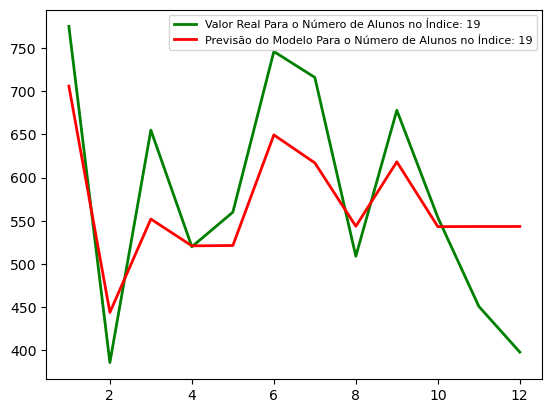

In [ ]:
plt.plot(x, x_test, 'green', lw = 2, label = 'Valor Real Para o Número de Alunos no Índice: {}'.format(index))
plt.plot(x, pred, 'red', lw = 2, label = 'Previsão do Modelo Para o Número de Alunos no Índice: {}'.format(index))
plt.legend(fontsize = 8)
plt.show()